**TRABALHO SOBRE TIPOS DE ARROZ COLETADOS POR IMAGEM (CAMMEO OU OSMANCIK)**

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import importlib
import plotly.express as px
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.mixture import GaussianMixture
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

In [2]:
rice_df = pd.read_csv('Rice.csv')
rice_df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


In [3]:
rice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   str    
dtypes: float64(5), int64(2), str(1)
memory usage: 238.3 KB


In [4]:
rice_df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144752,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [5]:
rice_df_SC = rice_df.drop('Class',axis = 1)
scaler = StandardScaler()
rice_df_normalizado = scaler.fit_transform(rice_df_SC)

In [6]:
pca = PCA(n_components = 2)
y_pca = rice_df['Class']
x_pca = pca.fit_transform(rice_df_normalizado)
pca.explained_variance_ratio_

array([0.65413989, 0.21425124])

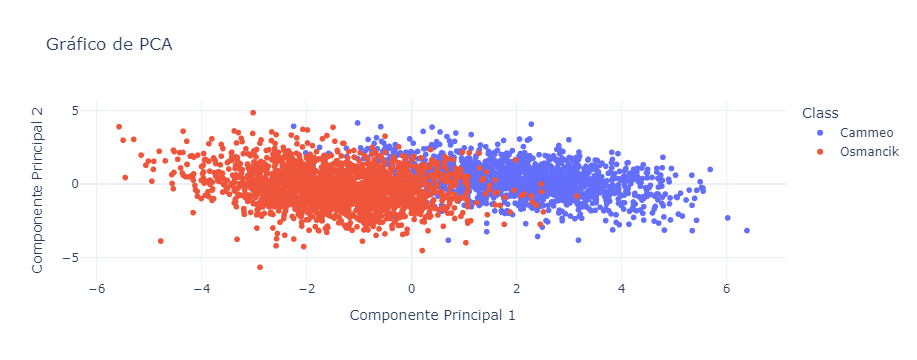

In [7]:
pca_df = pd.DataFrame(data = x_pca, columns = ['PC1', 'PC2'])
pca_df['Class'] = rice_df['Class'].values
fig = px.scatter(pca_df, x = 'PC1', y = 'PC2', color = 'Class',
                 title = ' Gráfico de PCA ',
                 labels = {'PC1' : 'Componente Principal 1', 'PC2' : 'Componente Principal 2'},
                 template = 'plotly_white')
fig.show()


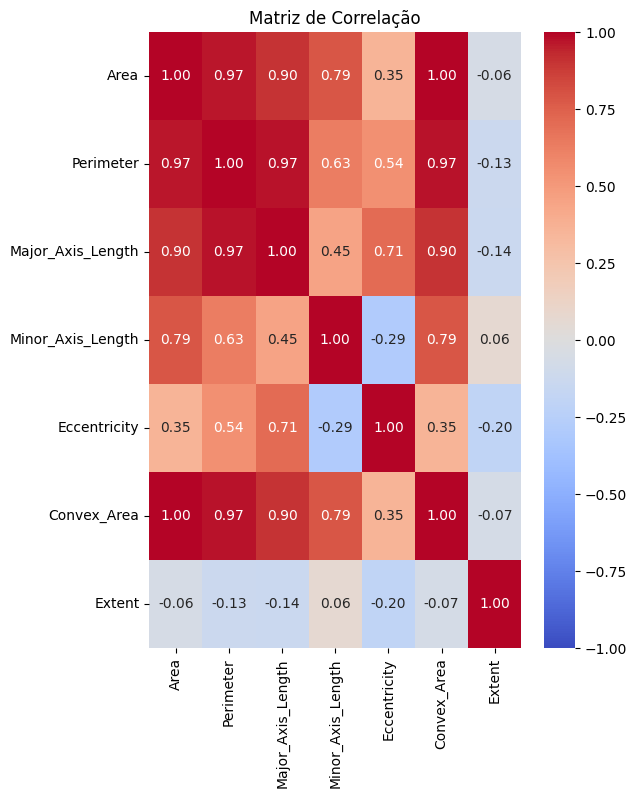

In [8]:
plt.figure(figsize = (6,8))
sns.heatmap(rice_df_SC.corr(), annot = True, cmap = 'coolwarm', vmax = 1, vmin = -1,fmt = ".2f")
plt.title('Matriz de Correlação')
plt.show()

Sairei agora um pouco da parte relacional e explorarei as colunas em relação a um todo, farei a distribuição de frequencia, para saber se possuem uma predominancia de alguma faixa de valores presente dentro das minhas colunas. Farei 5 colunas para cada gráfico, calcularei o intevalo pela subtração do maior e menor, após realizei a divisão por 5, depois adicionei aos poucos até q abranjecem todos os números da coluna realizada(utilizei as informações do .describe()).

In [9]:
intervalo_area = [7551.0,9823.4,12095.8,14368.2,16640.6,18913.0]
categoria = pd.cut(rice_df['Area'], intervalo_area)
frequencia_area = categoria.value_counts()
tabela = pd.DataFrame({
    'Frequência': frequencia_area,
    'Porcentagem (%)': (frequencia_area / frequencia_area.sum() * 100).round(2)
})
print(tabela)

                    Frequência  Porcentagem (%)
Area                                           
(9823.4, 12095.8]         1504            39.49
(12095.8, 14368.2]        1449            38.04
(14368.2, 16640.6]         700            18.38
(7551.0, 9823.4]           114             2.99
(16640.6, 18913.0]          42             1.10


In [10]:
intervalo_perimetro = [359.1,396.96,434.82,472.71,510.57,548.46]
categoria2 = pd.cut(rice_df['Perimeter'], intervalo_perimetro)
frequencia_perimetro = categoria2.value_counts()
print(frequencia_perimetro)

Perimeter
(396.96, 434.82]    1263
(434.82, 472.71]    1171
(472.71, 510.57]    1028
(510.57, 548.46]     239
(359.1, 396.96]      109
Name: count, dtype: int64


In [11]:
intervalo_maior = [145.2, 163.9,182.7,201.4,220.24,239.1]
categoria3 = pd.cut(rice_df['Major_Axis_Length'], intervalo_maior)
frequencia_intervalo_maior = categoria3.value_counts() 
print(frequencia_intervalo_maior)

Major_Axis_Length
(163.9, 182.7]     1532
(182.7, 201.4]     1019
(201.4, 220.24]     958
(145.2, 163.9]      177
(220.24, 239.1]     124
Name: count, dtype: int64


In [12]:
intervalo_menor = [59.5,69.1,78.7,88.3,97.9,107.6]
categoria4 = pd.cut(rice_df['Minor_Axis_Length'],intervalo_menor)
frequencia_menor = categoria4.value_counts()
print(frequencia_menor)

Minor_Axis_Length
(78.7, 88.3]     2117
(88.3, 97.9]     1276
(69.1, 78.7]      324
(97.9, 107.6]      81
(59.5, 69.1]       12
Name: count, dtype: int64


In [13]:
intervalo_ecentricidade = [0.777,0.811,0.845,0.879,0.913,0.949]
categoria5 = pd.cut(rice_df['Eccentricity'], intervalo_ecentricidade)
frequencia_ecc = categoria5.value_counts()
print(frequencia_ecc)

Eccentricity
(0.879, 0.913]    2161
(0.845, 0.879]    1217
(0.913, 0.949]     331
(0.811, 0.845]      97
(0.777, 0.811]       4
Name: count, dtype: int64


In [14]:
intervalo_Conv = [7723,9998.2,12273.4,14548.6,16823.8,19099]
categoria6 = pd.cut(rice_df['Convex_Area'],intervalo_Conv)
frequencia_Conv = categoria6.value_counts()
print(frequencia_Conv)

Convex_Area
(12273.4, 14548.6]    1451
(9998.2, 12273.4]     1428
(14548.6, 16823.8]     761
(7723.0, 9998.2]       102
(16823.8, 19099.0]      67
Name: count, dtype: int64


In [15]:
intervalo_Ex = [0.497,0.569,0.6426,0.715,0.7882,0.862]
categoria7 = pd.cut(rice_df['Extent'], intervalo_Ex)
frequencia_Ex = categoria7.value_counts()
print(frequencia_Ex)

Extent
(0.569, 0.643]    1528
(0.643, 0.715]     862
(0.715, 0.788]     818
(0.497, 0.569]     340
(0.788, 0.862]     262
Name: count, dtype: int64


In [16]:
frequencia_Class = rice_df['Class'].value_counts()
print(frequencia_Class)

Class
Osmancik    2180
Cammeo      1630
Name: count, dtype: int64


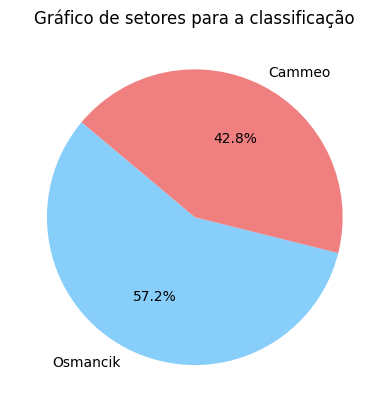

In [17]:
cores = ['lightskyblue','lightcoral']
categoria = ['Osmancik', 'Cammeo']
plt.pie(frequencia_Class, labels = categoria, colors = cores, autopct = '%.1f%%', startangle = 140)
plt.title('Gráfico de setores para a classificação')
plt.show()

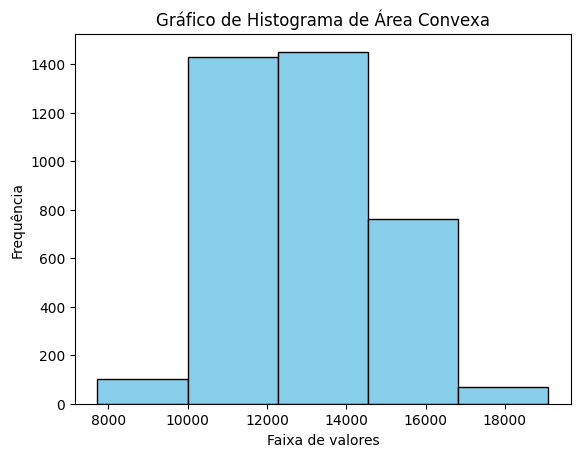

In [18]:
area_C = rice_df['Convex_Area']
plt.hist(area_C, bins = 5, color = 'skyblue', edgecolor = 'black')
plt.title('Gráfico de Histograma de Área Convexa')
plt.xlabel('Faixa de valores')
plt.ylabel('Frequência')
plt.show()

Text(0.5, 1.0, 'Boxplot do menor eixo')

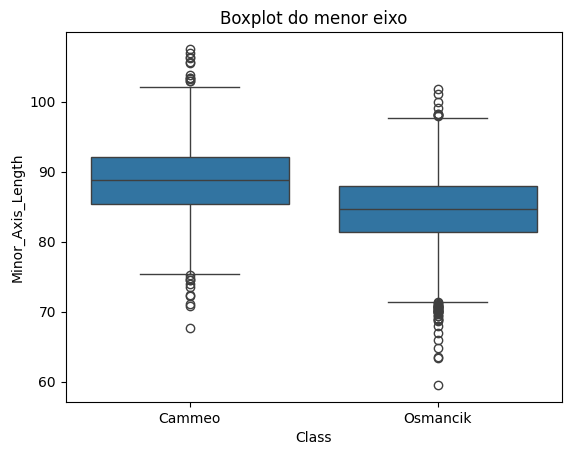

In [19]:
sns.boxplot(x = 'Class',y = 'Minor_Axis_Length', data = rice_df)
plt.title('Boxplot do menor eixo')

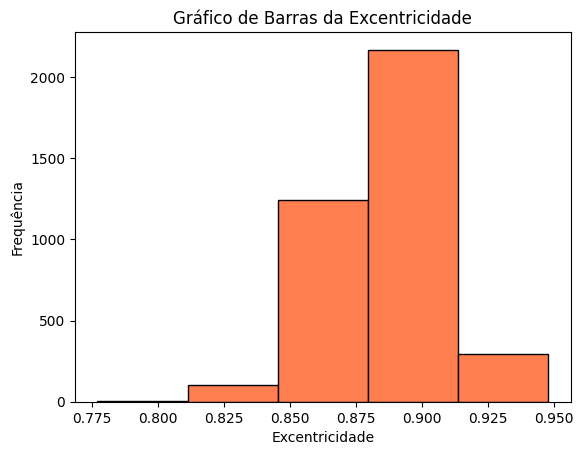

In [20]:
eccentricidade = rice_df['Eccentricity']
plt.hist(eccentricidade, bins = 5, color = 'coral', edgecolor = 'black')
plt.title('Gráfico de Barras da Excentricidade')
plt.xlabel('Excentricidade')
plt.ylabel('Frequência')
plt.show()

Tendência Central

Média:

In [21]:
rice_df_SC.mean()

Area                 12667.727559
Perimeter              454.239180
Major_Axis_Length      188.776222
Minor_Axis_Length       86.313750
Eccentricity             0.886871
Convex_Area          12952.496850
Extent                   0.661934
dtype: float64

Mediana:

In [22]:
rice_df_SC.median()

Area                 12421.500000
Perimeter              448.852493
Major_Axis_Length      185.810059
Minor_Axis_Length       86.434647
Eccentricity             0.889050
Convex_Area          12706.500000
Extent                   0.645361
dtype: float64

Ponto Médio:

In [23]:
ponto_medio = (rice_df_SC.max() + rice_df_SC.min())/2
print(ponto_medio)

Area                 13232.000000
Perimeter              453.772995
Major_Axis_Length      192.137482
Minor_Axis_Length       83.537428
Eccentricity             0.862620
Convex_Area          13411.000000
Extent                   0.679231
dtype: float64


Moda:

In [24]:
rice_df_SC.mode()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
0,11422.0,432.298004,184.875732,86.279121,0.871757,11132.0,0.588235
1,11923.0,NaN,190.673599,86.660088,0.873854,11628.0,0.605475
2,12692.0,NaN,NaN,86.758720,0.884616,11845.0,0.658327
3,13002.0,NaN,NaN,87.042526,0.892600,13562.0,0.694695
4,14850.0,NaN,NaN,89.786987,0.895920,NaN,0.739130
5,NaN,NaN,NaN,90.224045,0.899393,NaN,0.779280
6,NaN,NaN,NaN,NaN,0.909403,NaN,NaN


Medidas de Dispersão

Amplitude:

In [25]:
Amplitude = rice_df_SC.max()-rice_df_SC.min()
print(Amplitude)

Area                 11362.000000
Perimeter              189.345978
Major_Axis_Length       93.746033
Minor_Axis_Length       48.010044
Eccentricity             0.170774
Convex_Area          11376.000000
Extent                   0.363637
dtype: float64


In [26]:
rice_df_SC.var()

Area                 3.001098e+06
Perimeter            1.267152e+03
Major_Axis_Length    3.044564e+02
Minor_Axis_Length    3.283081e+01
Eccentricity         4.333739e-04
Convex_Area          3.157630e+06
Extent               5.965828e-03
dtype: float64

In [27]:
rice_df_SC.std()

Area                 1732.367706
Perimeter              35.597081
Major_Axis_Length      17.448679
Minor_Axis_Length       5.729817
Eccentricity            0.020818
Convex_Area          1776.972042
Extent                  0.077239
dtype: float64

In [28]:
coef_var = (rice_df_SC.std()/rice_df_SC.mean())*100
print(coef_var)

Area                 13.675442
Perimeter             7.836638
Major_Axis_Length     9.243049
Minor_Axis_Length     6.638360
Eccentricity          2.347314
Convex_Area          13.719147
Extent               11.668651
dtype: float64


Medidas de Posição Relativa

Quartis:

In [29]:
rice_df_SC.quantile([0.25,0.5,0.75])

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
0.25,11370.5,426.144752,174.353855,82.731695,0.872402,11626.25,0.598862
0.50,12421.5,448.852493,185.810059,86.434647,0.889050,12706.50,0.645361
0.75,13950.0,483.683746,203.550438,90.143677,0.902588,14284.00,0.726562


Implementarei o método do kmeans, já que procuro saber se consigo dividir de forma correta os dados, com base previamente no que o método do cotovelo apresentar, já que ele apresenta a quantidade de clusters que eu consigo atingir um bom erro quadrático. Então aliarei essa análise com a quantidade de classificações que possuo(provavelmente escolherei a quantidade de 2 clusters). Sendo o objetivo dessa implementação conseguir dividir da melhor forma os dados para saber quantos possuem caracteristicas semelhantes.

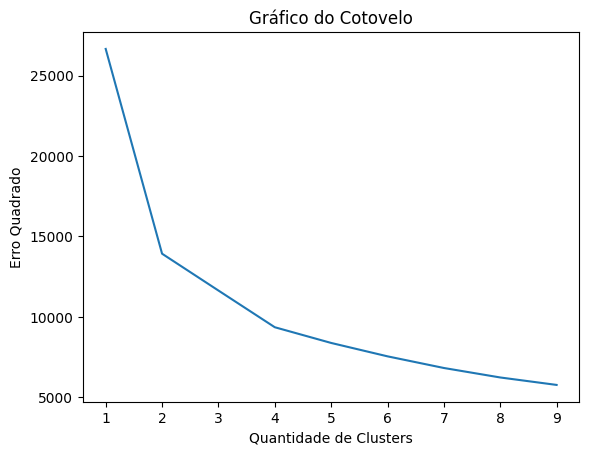

In [30]:
inercia = []
for k in range(1,10):
    analise = KMeans(n_clusters = k, random_state = 42)
    analise.fit(rice_df_normalizado)
    inercia.append(analise.inertia_)

plt.plot(range(1,10), inercia)
plt.xlabel("Quantidade de Clusters")
plt.ylabel("Erro Quadrado")
plt.title("Gráfico do Cotovelo")
plt.show()

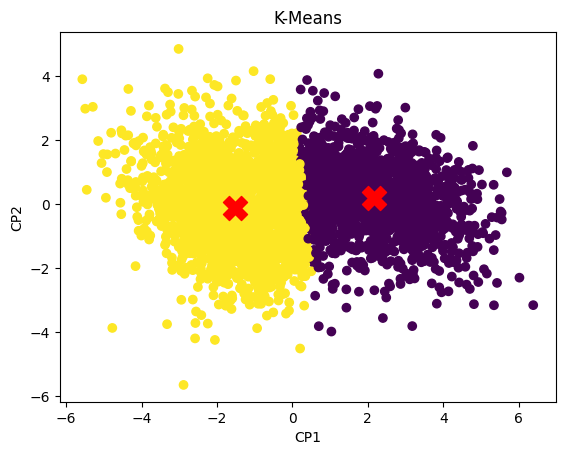

In [57]:
kmeans =KMeans(n_clusters = 2, random_state = 42)
kmeans.fit(rice_df_normalizado)

centroides = pca.transform(kmeans.cluster_centers_)

plt.scatter( 
    x_pca[:,0],
    x_pca[:,1],
    c = kmeans.labels_
)
plt.scatter( 
    centroides[:,0],
    centroides[:,1],
    marker ='X',
    s = 300,
    c = 'red'
)
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.title("K-Means")
plt.show()

Pode-se percerber que o decrescimento da quantidade de erros por meio da visualização do método do cotovelo é notória, algo esperado com o aumento do número de pontos, já que aumentaria a identificação dos mesmos com os centroides acrescidos, caso a distancia fosse menor, quando comparada com menos pontos.
Como já havia dito, mantive os dois centroides devido ao rótulo, e também levando em conta uma melhor visualização do comportamento. Utilizei o pca para uma vizualização mais clara, já que possuo 7 colunas, sem contar a classificação(não usada), com isso consigo resumir de forma clara os dados, sem que os eixos parecessem faltosos, além das colocações dos pontos mais claras.

Com o gráfico do kmeans foi possível observar uma separação forte e acertiva quando comparado com o gráfico supervisionado do PCA, já que observamos pontos separados de forma semelhante com as classificações de tipos de arroz, ou seja, a média dos dois centroides tiveram uma boa correspondência com a divisão real.



Partirei para a implementação de métodos de machine learn, começando pelo decision tree, em que aplicarei para os meus dados e verei se esse modelo consegue abranjer da melhor forma possível eles de acordo com sua classificação, através dos parâmetros numéricos calculados pelo modelo, já que ele vai achar os que mais definem o tipo de arroz.

GMM:

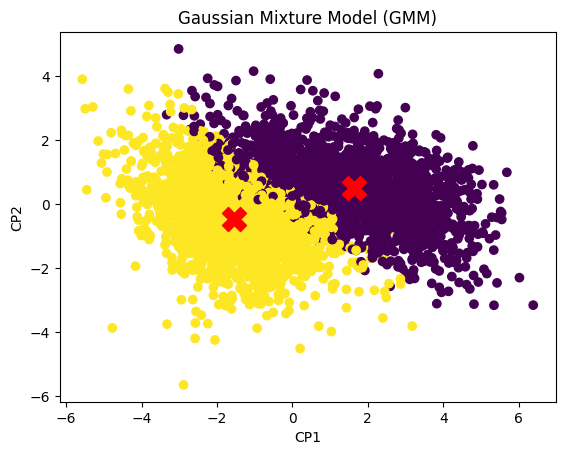

In [56]:
gmm = GaussianMixture(
    n_components=2,
    random_state=42
)

gmm.fit(rice_df_normalizado)
labels = gmm.predict(rice_df_normalizado)
centroides = pca.transform(gmm.means_)

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=labels
)

plt.scatter(
    centroides[:,0],
    centroides[:,1],
    marker='X',
    s=300,
    c='red'
)

plt.xlabel("CP1")
plt.ylabel("CP2")
plt.title("Gaussian Mixture Model (GMM)")
plt.show()

O algoritmo Gaussian Mixture Model (GMM) foi aplicado ao dataset Rice com o objetivo de identificar agrupamentos naturais entre os grãos das variedades Cammeo e Osmancik. Diferentemente do K-Means, que atribui cada amostra a um único grupo de forma rígida, o GMM utiliza distribuições gaussianas para modelar os clusters, permitindo uma classificação probabilística. Dessa forma, cada grão recebe uma probabilidade de pertencer a cada grupo, tornando o modelo mais flexível para lidar com sobreposições entre classes. Após o treinamento com dois componentes gaussianos, os resultados foram visualizados utilizando a redução de dimensionalidade por PCA, possibilitando observar a distribuição dos clusters e a posição de seus centroides no espaço bidimensional.

In [32]:
X = rice_df_SC
y = rice_df['Class']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
modelo = DecisionTreeClassifier(max_depth = 4, random_state = 42)

modelo.fit(X_train,y_train)
pred = modelo.predict(X_test)

acc = accuracy_score(y_test,pred)
print(f"Porcentagem de acerto do Decision Tree: {acc:.2%}")


Porcentagem de acerto do Decision Tree: 93.00%


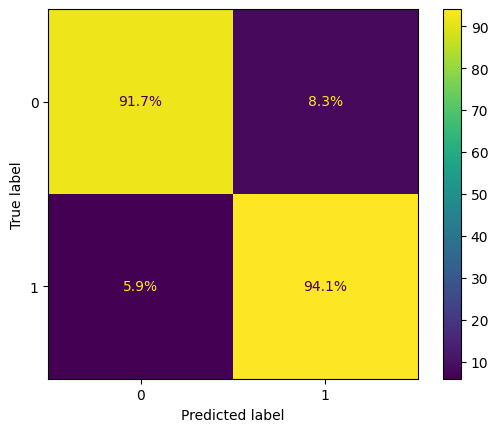

In [33]:
cm = confusion_matrix(y_test, pred, normalize='true') * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='.1f')

# Adiciona o símbolo %
for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.show()

In [34]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

      Cammeo       0.93      0.92      0.92       518
    Osmancik       0.93      0.94      0.94       625

    accuracy                           0.93      1143
   macro avg       0.93      0.93      0.93      1143
weighted avg       0.93      0.93      0.93      1143



In [35]:
print(cross_val_score(modelo,X,y,cv=5))

[0.93044619 0.9343832  0.92388451 0.93175853 0.8832021 ]


In [36]:
print(f"Taxa de acertividade da validação cruzada (no Decision Tree): {((0.93044619+0.9343832+0.92388451+0.93175853+0.8832021)/5):.2%}")

Taxa de acertividade da validação cruzada (no Decision Tree): 92.07%


Pode-se perceber que o modelo Decision Tree apresentou uma alta taxa de acerto no que diz respeito a acurácia, já que acertou 93% dos dados testados, oque não se distancia da validação cruzada, mostrando uma certa consistencia nos atributos dos dados recolhidos do dataset, sendo o valor da validação cruzada de 92.07%. Além de possuirem bons resultados quando comparada a acertividade entre si, que é o caso do classification report.

In [37]:
X = rice_df_normalizado
y = rice_df['Class']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state=42)
knn = KNeighborsClassifier(n_neighbors = 5)

knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
acuracia = accuracy_score(y_test,y_pred)

print(f"Porcentagem de acerto do KNN: {acuracia:.2%}")

Porcentagem de acerto do KNN: 91.43%


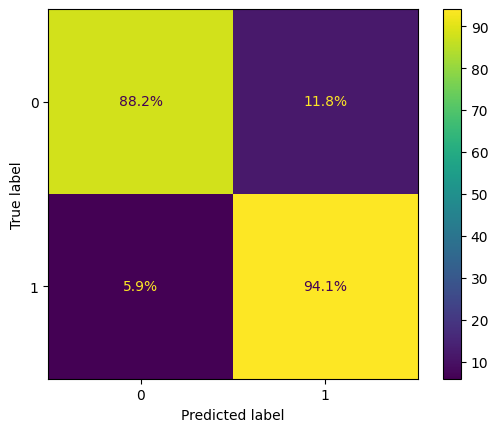

In [51]:
cm = confusion_matrix(y_test, y_pred, normalize='true') * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='.1f')

# Adiciona o símbolo %
for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.show()

In [39]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

      Cammeo       0.93      0.88      0.90       518
    Osmancik       0.91      0.94      0.92       625

    accuracy                           0.91      1143
   macro avg       0.92      0.91      0.91      1143
weighted avg       0.91      0.91      0.91      1143



In [40]:
print(cross_val_score(knn,X,y,cv=5))

[0.93044619 0.93569554 0.9160105  0.92388451 0.88713911]


In [41]:
print(f"Taxa de acerto da validação cruzada (no KNN): {((0.93044619+0.93569554+0.9160105+0.92388451+0.88713911)/5):.2%}")

Taxa de acerto da validação cruzada (no KNN): 91.86%


Com a utilização do Knn, forma linear de classificação, com análise dos 5 vizinhos mais próximos, obtive a porcentagem de acertividade de 91.43% dos teste, sendo uma alta porcentagem, um pouco menor que a do decision tree, porém também possui uma excelente capacidade de classificação nesse dataset. A validação cruzada, nesse caso, obteve uma maior porcentagem que a propriamente extraida inicialmente com a implementação do modelo, mas de certa forma semelhantes, com uma pequena diferença de 0.43%.

Aplicarei o SVM para testar o modelo, tendo em vista que ele apresenta uma abordagem diferente dos outros modelos, já que tem como parametro uma função de reta.

In [53]:
X = rice_df_normalizado
y = rice_df['Class']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state = 42)

model = SVC(kernel = 'rbf', C = 1)
model.fit(X_train,y_train)

previsao = model.predict(X_test)
conferir = accuracy_score(y_test,previsao)
print(f"Porcentagem de acerto do SVM: {conferir:.2%}")

Porcentagem de acerto do SVM: 93.09%


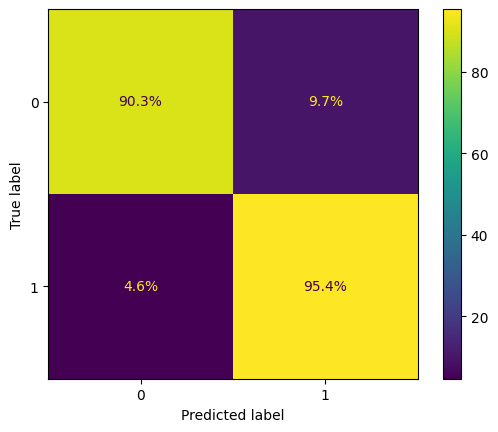

In [54]:
cm = confusion_matrix(y_test, previsao, normalize='true') * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='.1f')

# Adiciona o símbolo %
for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.show()

In [44]:
print(classification_report(y_test,previsao))
print(cross_val_score(modelo,X,y,cv =5))

              precision    recall  f1-score   support

      Cammeo       0.94      0.90      0.92       518
    Osmancik       0.92      0.95      0.94       625

    accuracy                           0.93      1143
   macro avg       0.93      0.93      0.93      1143
weighted avg       0.93      0.93      0.93      1143

[0.93044619 0.9343832  0.92388451 0.93175853 0.8832021 ]


In [45]:
print(f"Taxa de acertividade da validação cruzada (SVM): {(0.93044619+0.9343832+0.92388451+0.93175853+0.8832021)/5:.2%}")

Taxa de acertividade da validação cruzada (SVM): 92.07%


Percebe-se que o modelo apresentou, em relação a um todo, uma boa porcentagem de acerto, sendo de 93%, sendo o modelo, com 0.03% a frente do decision tree, que apresenta a maior acertividade, oque mostra a característica dos dados de se comportarem bem linearmente e possuirem pouca quantidade de distúrbios em relação a classificação.

In [46]:
rna = MLPClassifier(
    hidden_layer_sizes=(16,8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)
rna.fit(X_train, y_train)
pred = rna.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"Porcentagem de acerto da Rede Neural: {acc:.2%}")


Porcentagem de acerto da Rede Neural: 93.09%


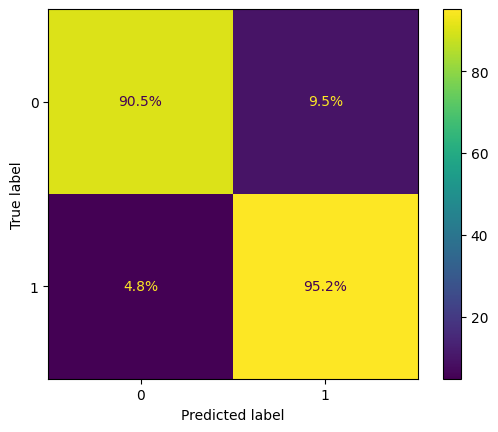

In [55]:
cm = confusion_matrix(y_test, pred, normalize='true') * 100

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format='.1f')

for text in disp.text_.ravel():
    text.set_text(text.get_text() + '%')

plt.show()

In [48]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

      Cammeo       0.94      0.91      0.92       518
    Osmancik       0.92      0.95      0.94       625

    accuracy                           0.93      1143
   macro avg       0.93      0.93      0.93      1143
weighted avg       0.93      0.93      0.93      1143



In [49]:
print(cross_val_score(rna, X, y, cv=5))

[0.93963255 0.94750656 0.92650919 0.93307087 0.89238845]


In [50]:
print(f"Taxa de acertividade da validação cruzada (Rede Neural): {(0.93963255+0.94750656+0.92650919+0.93307087+0.89238845)/5:.2%}")

Taxa de acertividade da validação cruzada (Rede Neural): 92.78%
